# Classification using Logistic Regression

## Problem Statement
- Predict whether the patient will suffer with hearing problem
- test_result will be the independent varibale
- age and physical_score will be independent varibales

### Import required packages

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Load the data

In [2]:
df = pd.read_csv("./hearing_test.csv")

### Exploratory data analysis

In [3]:
# Get the general information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             5000 non-null   float64
 1   physical_score  5000 non-null   float64
 2   test_result     5000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 117.3 KB


In [4]:
# Get stastical information
df.describe()

,age,physical_score,test_result
count,5000.000000,5000.000000,5000.000000
mean,51.609000,32.760260,0.600000
std,11.287001,8.169802,0.489947
min,18.000000,-0.000000,0.000000
25%,43.000000,26.700000,0.000000
50%,51.000000,35.300000,1.000000
75%,60.000000,38.900000,1.000000
max,90.000000,50.000000,1.000000


In [5]:
# Check if any missing values
df.isna().sum()

age               0
physical_score    0
test_result       0
dtype: int64

In [6]:
# Check if dataset is balanced
df['test_result'].value_counts()

test_result
1    3000
0    2000
Name: count, dtype: int64

<BarContainer object of 2 artists>

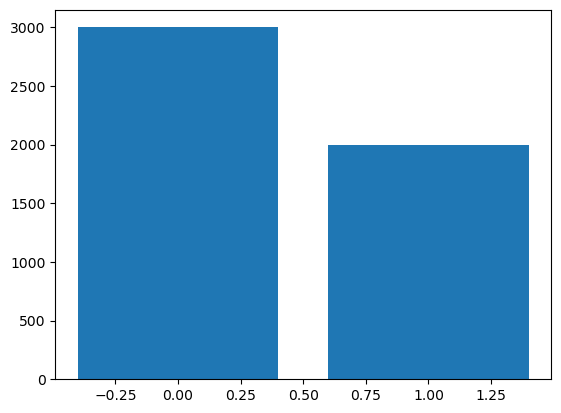

In [7]:
# Check if dataset is balanced 
plt.bar(np.arange(2), df['test_result'].value_counts())

### Split the data

In [12]:
# Split the data into x and y
x = df.drop('test_result', axis = 1)
y = df['test_result']

In [14]:
# Split the data into train and test
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = 0.8 , random_state = 42)

### Train a model

In [15]:
from sklearn.linear_model import LogisticRegressionCV

# Create a model
model = LogisticRegressionCV()

# Train the model
model.fit(x_train, y_train)

,Cs,10
,fit_intercept,True
,cv,None
,dual,False
,penalty,'l2'
,scoring,None
,solver,'lbfgs'
,tol,0.0001
,max_iter,100
,class_weight,None
,n_jobs,None


### Evaluate the model

In [19]:
# Evaluate on train set
model.score(x_train , y_train)

0.9215

In [20]:
# Evaluate on testing set
model.score(x_test, y_test)

0.892

### Result visualization

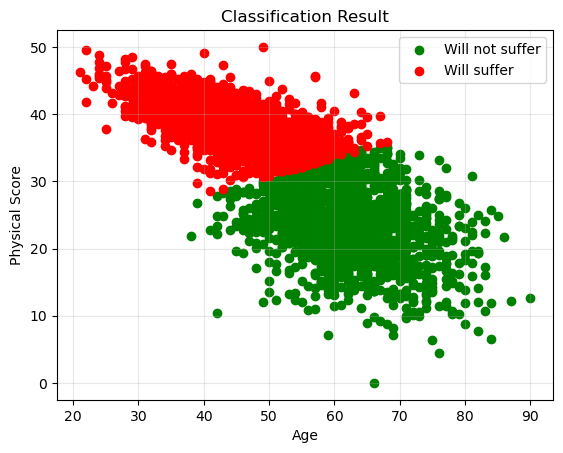

In [24]:
# Predict the values
y_pred = model.predict(x_train)

# Use two independent varibale on x and y
plt.scatter(
    x_train['age'][y_pred == 0],
    x_train['physical_score'][y_pred == 0],
    color = "green",
    label = "Will not suffer"
)
plt.scatter(
    x_train['age'][y_pred == 1],
    x_train['physical_score'][y_pred == 1],
    color = "red",
    label = "Will suffer"
)

plt.title("Classification Result")
plt.xlabel("Age")
plt.ylabel("Physical Score")
plt.grid(alpha = 0.3)
plt.legend()